In [1]:
# CELL 1: INSTALL DEPENDENCIES
# ============================================
!pip install ultralytics easyocr opencv-python matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 113.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 33.6 MB/s eta 0:00:00


In [2]:
# CELL 2: IMPORT LIBRARIES AND VERIFY VERSIONS
# ============================================
import ultralytics
import easyocr
import cv2
import matplotlib
import numpy

print("Ultralytics version:", ultralytics.__version__)
print("EasyOCR version:", easyocr.__version__)
print("OpenCV version:", cv2.__version__)
print("NumPy version:", numpy.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.48
EasyOCR version: 1.7.2
OpenCV version: 4.13.0
NumPy version: 2.0.2


In [ ]:
# CELL 3: CHECK GPU AVAILABILITY
# ============================================
!nvidia-smi

Sun May 10 07:51:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# CELL 4: CREATE PROJECT DIRECTORY STRUCTURE
# ============================================
import os

PROJECT_ROOT = "/content/ANPR_System"

directories = [
    "data/images/train",
    "data/images/val",
    "data/images/test",
    "data/labels/train",
    "data/labels/val",
    "data/labels/test",
    "models",
    "notebooks",
    "src",
    "outputs",
    "samples"
]

for directory in directories:
    os.makedirs(os.path.join(PROJECT_ROOT, directory), exist_ok=True)

print("Project directory structure created at:", PROJECT_ROOT)

Project directory structure created at: /content/ANPR_System


In [4]:
# CELL 5: MOUNT GOOGLE DRIVE
# ============================================
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = "/content/drive/MyDrive/ANPR_System"
os.makedirs(DRIVE_PATH, exist_ok=True)

print("Google Drive mounted at:", DRIVE_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted at: /content/drive/MyDrive/ANPR_System


In [5]:
# CELL 1: DOWNLOAD DATASET FROM KAGGLE
import os
import shutil

# Kaggle dataset path
# The dataset is already in YOLO format and needs to be placed in the content directory
# Using the specific dataset identified in the search results
!pip install kaggle -q

# Upload kaggle.json for API access (you need to get this from your Kaggle account)
from google.colab import files
# files.upload()  # Uncomment to upload kaggle.json if not already set up

# Create .kaggle directory and move kaggle.json
!mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/  # Uncomment if you uploaded kaggle.json
!chmod 600 ~/.kaggle/kaggle.json 2>/dev/null || echo "If kaggle.json not found, download dataset manually"

# Download the specific Car License Plate Detection dataset in YOLO format
!kaggle datasets download sujaymann/car-number-plate-dataset-yolo-format -p /content/ --unzip

print("Dataset downloaded and extracted.")

If kaggle.json not found, download dataset manually
Dataset URL: https://www.kaggle.com/datasets/sujaymann/car-number-plate-dataset-yolo-format
License(s): Community Data License Agreement - Sharing - Version 1.0
100% 203M/203M [00:12<00:00, 17.1MB/s]

Dataset downloaded and extracted.


In [6]:
# CELL 2: EXPLORE DATASET STRUCTURE AND STATISTICS
import os

# Path to the downloaded dataset
dataset_path = "/content/License-Plate-Data"

# Count images in train and test sets
train_images_path = os.path.join(dataset_path, "train", "images")
test_images_path = os.path.join(dataset_path, "test", "images")

def count_files(directory):
    if os.path.exists(directory):
        return len([f for f in os.listdir(directory) if f.endswith('.png') or f.endswith('.jpg')])
    return 0

train_count = count_files(train_images_path)
test_count = count_files(test_images_path)

print(f"Total training images: {train_count}")
print(f"Total test images: {test_count}")
print(f"Total dataset images: {train_count + test_count}")

# Check annotation format - print first label file content
label_path = os.path.join(dataset_path, "train", "labels")
if os.path.exists(label_path):
    label_files = [f for f in os.listdir(label_path) if f.endswith('.txt')]
    if label_files:
        with open(os.path.join(label_path, label_files[0]), 'r') as f:
            first_label = f.read()
        print(f"\nAnnotation format (first file): {first_label}")
        print("Format: class_id x_center y_center width height (all normalized 0-1)")

# Check image sizes
import cv2
image_files = [f for f in os.listdir(train_images_path) if f.endswith('.png') or f.endswith('.jpg')]
if image_files:
    sample_image = cv2.imread(os.path.join(train_images_path, image_files[0]))
    if sample_image is not None:
        height, width = sample_image.shape[:2]
        print(f"\nSample image size: {width}x{height}")

Total training images: 346
Total test images: 87
Total dataset images: 433

Annotation format (first file): 0 0.6966666666666668 0.475 0.053333333333333344 0.024999999999999967
Format: class_id x_center y_center width height (all normalized 0-1)

Sample image size: 375x500


In [7]:
# CELL 3: RE-SPLIT DATASET 70/20/10 AND CREATE NEW STRUCTURE
import os
import shutil
from sklearn.model_selection import train_test_split
import random

# Source paths
source_images = os.path.join(dataset_path, "train", "images")
source_labels = os.path.join(dataset_path, "train", "labels")

# Target project path
project_data = "/content/ANPR_System/data"

# Get all image files
image_files = [f for f in os.listdir(source_images) if f.endswith('.png') or f.endswith('.jpg')]
total_images = len(image_files)

print(f"Total images to split: {total_images}")

# First split: separate out test set (10%)
train_val_files, test_files = train_test_split(
    image_files,
    test_size=0.10,
    random_state=42
)

# Second split: separate train (70%) and validation (20%)
# After removing 10% test, we need 20/90 = 0.222 of remaining for validation
train_files, val_files = train_test_split(
    train_val_files,
    test_size=0.2222,
    random_state=42
)

print(f"Train set: {len(train_files)} images ({len(train_files)/total_images*100:.1f}%)")
print(f"Validation set: {len(val_files)} images ({len(val_files)/total_images*100:.1f}%)")
print(f"Test set: {len(test_files)} images ({len(test_files)/total_images*100:.1f}%)")

# Function to copy files
def copy_files(file_list, source_img_dir, source_lbl_dir, dest_img_dir, dest_lbl_dir):
    os.makedirs(dest_img_dir, exist_ok=True)
    os.makedirs(dest_lbl_dir, exist_ok=True)

    for filename in file_list:
        # Copy image
        img_source = os.path.join(source_img_dir, filename)
        img_dest = os.path.join(dest_img_dir, filename)
        shutil.copy2(img_source, img_dest)

        # Copy corresponding label
        label_name = filename.rsplit('.', 1)[0] + '.txt'
        lbl_source = os.path.join(source_lbl_dir, label_name)
        lbl_dest = os.path.join(dest_lbl_dir, label_name)
        if os.path.exists(lbl_source):
            shutil.copy2(lbl_source, lbl_dest)

# Copy files to new structure
copy_files(train_files, source_images, source_labels,
           os.path.join(project_data, "images", "train"),
           os.path.join(project_data, "labels", "train"))

copy_files(val_files, source_images, source_labels,
           os.path.join(project_data, "images", "val"),
           os.path.join(project_data, "labels", "val"))

copy_files(test_files, source_images, source_labels,
           os.path.join(project_data, "images", "test"),
           os.path.join(project_data, "labels", "test"))

print("\nDataset re-split complete. New structure created under /content/ANPR_System/data/")

Total images to split: 346
Train set: 241 images (69.7%)
Validation set: 70 images (20.2%)
Test set: 35 images (10.1%)

Dataset re-split complete. New structure created under /content/ANPR_System/data/


In [8]:
# CELL 4: CREATE DATA.YAML CONFIGURATION FILE
yaml_content = """
# YOLOv8 data.yaml configuration
# Paths are relative to the Colab environment
train: /content/ANPR_System/data/images/train
val: /content/ANPR_System/data/images/val
test: /content/ANPR_System/data/images/test

# Number of classes
nc: 1

# Class names
names: ['license_plate']
"""

yaml_path = os.path.join(project_data, "data.yaml")
with open(yaml_path, 'w') as f:
    f.write(yaml_content.strip())

print(f"data.yaml created at: {yaml_path}")
print("\nContent of data.yaml:")
with open(yaml_path, 'r') as f:
    print(f.read())

data.yaml created at: /content/ANPR_System/data/data.yaml

Content of data.yaml:
# YOLOv8 data.yaml configuration
# Paths are relative to the Colab environment
train: /content/ANPR_System/data/images/train
val: /content/ANPR_System/data/images/val
test: /content/ANPR_System/data/images/test

# Number of classes
nc: 1

# Class names
names: ['license_plate']


In [9]:
# CELL 5: HANDLE CORRUPT OR MISSING IMAGES
import cv2
import os

def validate_dataset():
    """Check for corrupt images and missing label files"""
    splits = ['train', 'val', 'test']
    corrupt_files = []
    missing_labels = []

    for split in splits:
        img_dir = os.path.join(project_data, "images", split)
        lbl_dir = os.path.join(project_data, "labels", split)

        if not os.path.exists(img_dir):
            continue

        for img_file in os.listdir(img_dir):
            if not img_file.endswith(('.png', '.jpg')):
                continue

            img_path = os.path.join(img_dir, img_file)

            # Check if image can be opened
            img = cv2.imread(img_path)
            if img is None:
                corrupt_files.append(img_path)
                continue

            # Check if corresponding label exists
            label_file = img_file.rsplit('.', 1)[0] + '.txt'
            lbl_path = os.path.join(lbl_dir, label_file)
            if not os.path.exists(lbl_path):
                missing_labels.append(img_path)

    return corrupt_files, missing_labels

corrupt_images, missing_labels = validate_dataset()

if corrupt_images:
    print(f"Warning: Found {len(corrupt_images)} corrupt images:")
    for f in corrupt_images:
        print(f"  - {f}")
else:
    print("No corrupt images found. All images readable.")

if missing_labels:
    print(f"\nWarning: Found {len(missing_labels)} images without labels:")
    for f in missing_labels:
        print(f"  - {f}")
else:
    print("No missing labels. Every image has a corresponding annotation file.")

print("\nDataset validation complete.")

No corrupt images found. All images readable.
No missing labels. Every image has a corresponding annotation file.

Dataset validation complete.


In [10]:
# CELL 6: FINAL DIRECTORY STRUCTURE VERIFICATION
def print_directory_tree(directory, prefix=""):
    """Print the directory structure in a tree format"""
    if not os.path.exists(directory):
        return

    items = sorted(os.listdir(directory))
    for i, item in enumerate(items):
        path = os.path.join(directory, item)
        is_last = i == len(items) - 1

        print(f"{prefix}{'└── ' if is_last else '├── '}{item}")

        if os.path.isdir(path):
            next_prefix = prefix + ("    " if is_last else "│   ")
            print_directory_tree(path, next_prefix)

print("ANPR System Project Structure:")
print("==============================")
print_directory_tree("/content/ANPR_System/data")

# Summary statistics
print("\n" + "="*30)
print("DATASET SUMMARY")
print("="*30)
for split in ['train', 'val', 'test']:
    img_dir = os.path.join(project_data, "images", split)
    lbl_dir = os.path.join(project_data, "labels", split)

    img_count = len([f for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg'))]) if os.path.exists(img_dir) else 0
    lbl_count = len([f for f in os.listdir(lbl_dir) if f.endswith('.txt')]) if os.path.exists(lbl_dir) else 0

    print(f"{split.upper():<10} Images: {img_count:<5} Labels: {lbl_count}")
print("="*30)

ANPR System Project Structure:
├── data.yaml
├── images
│   ├── test
│   │   ├── Cars100.png
│   │   ├── Cars125.png
│   │   ├── Cars145.png
│   │   ├── Cars16.png
│   │   ├── Cars19.png
│   │   ├── Cars211.png
│   │   ├── Cars213.png
│   │   ├── Cars217.png
│   │   ├── Cars226.png
│   │   ├── Cars256.png
│   │   ├── Cars267.png
│   │   ├── Cars268.png
│   │   ├── Cars274.png
│   │   ├── Cars295.png
│   │   ├── Cars297.png
│   │   ├── Cars304.png
│   │   ├── Cars312.png
│   │   ├── Cars317.png
│   │   ├── Cars337.png
│   │   ├── Cars341.png
│   │   ├── Cars356.png
│   │   ├── Cars37.png
│   │   ├── Cars377.png
│   │   ├── Cars383.png
│   │   ├── Cars386.png
│   │   ├── Cars41.png
│   │   ├── Cars410.png
│   │   ├── Cars417.png
│   │   ├── Cars425.png
│   │   ├── Cars48.png
│   │   ├── Cars49.png
│   │   ├── Cars60.png
│   │   ├── Cars64.png
│   │   ├── Cars80.png
│   │   └── Cars98.png
│   ├── train
│   │   ├── Cars0.png
│   │   ├── Cars1.png
│   │   ├── Cars102.png
│   │   ├── Cars103

In [11]:
# Install ultralytics package
!pip install ultralytics

# Also install other useful packages if needed
!pip install opencv-python matplotlib seaborn pillow

In [12]:
import os
from ultralytics import YOLO

# Define project paths
PROJECT_ROOT = "/content/drive/MyDrive/yolov8n.pt"
DATA_YAML = os.path.join(PROJECT_ROOT, "data", "data.yaml")
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")

# Load YOLOv8 nano pre-trained model
# The 'n' variant is the smallest and fastest, ideal for Colab free tier
model = YOLO('yolov8n.pt')
print("YOLOv8-nano model loaded successfully.")
print(f"Model has {sum(p.numel() for p in model.model.parameters()):,} parameters.")

YOLOv8-nano model loaded successfully.
Model has 3,157,200 parameters.


In [13]:
# Verify data.yaml exists and print its content for confirmation
yaml_path = DATA_YAML
if os.path.exists(yaml_path):
    with open(yaml_path, 'r') as f:
        print(f.read())
else:
    print(f"ERROR: {yaml_path} not found. Run Phase 2 first.")

ERROR: /content/drive/MyDrive/yolov8n.pt/data/data.yaml not found. Run Phase 2 first.


In [14]:
import os

search_path = "/content/drive/MyDrive"

for root, dirs, files in os.walk(search_path):
    for file in files:
        if file == "data.yaml":
            print(os.path.join(root, file))

/content/drive/MyDrive/License-Plate-Data/data.yaml


In [17]:
import os

dataset_path = "/content/drive/MyDrive/License-Plate-Data"
print("=== Folders inside dataset ===")
for item in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, item)
    if os.path.isdir(full_path):
        print("Folder:", item)
        for sub in os.listdir(full_path):
            print("   -", sub)

=== Folders inside dataset ===
Folder: test
   - images
   - labels
Folder: train
   - labels
   - images


In [18]:
with open("/content/drive/MyDrive/License-Plate-Data/data.yaml", "r") as f:
    content = f.read()
print(content)

names:
  0: license_plate
nc: 1
train: /kaggle/input/car-number-plate-dataset-yolo-format/License-Plate-Data/train
val: /kaggle/input/car-number-plate-dataset-yolo-format/License-Plate-Data/test


In [19]:
new_yaml_content = """names:
  0: license_plate
nc: 1
train: /content/drive/MyDrive/License-Plate-Data/train
val: /content/drive/MyDrive/License-Plate-Data/test
"""

with open("/content/drive/MyDrive/License-Plate-Data/data.yaml", "w") as f:
    f.write(new_yaml_content)

print("data.yaml updated successfully.")
print("New content:")
print(new_yaml_content)

data.yaml updated successfully.
New content:
names:
  0: license_plate
nc: 1
train: /content/drive/MyDrive/License-Plate-Data/train
val: /content/drive/MyDrive/License-Plate-Data/test



In [25]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sujaymann/car-number-plate-dataset-yolo-format")

print("Path to dataset files:", path)

100%|██████████| 203M/203M [00:13<00:00, 16.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sujaymann/car-number-plate-dataset-yolo-format/versions/3


In [26]:
import os

print("Dataset path:", path)
print("\nFolders inside:")
for item in os.listdir(path):
    print(" -", item)
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        for sub in os.listdir(item_path):
            print("    -", sub)

Dataset path: /root/.cache/kagglehub/datasets/sujaymann/car-number-plate-dataset-yolo-format/versions/3

Folders inside:
 - License-Plate-Data
    - data.yaml
    - test
    - train


In [27]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/sujaymann/car-number-plate-dataset-yolo-format/versions/3/License-Plate-Data"

# Check train labels
train_label_dir = os.path.join(dataset_path, "train", "labels")
sample_files = os.listdir(train_label_dir)[:5]

print("Sample label files:", sample_files)

# Read one label file
sample_path = os.path.join(train_label_dir, sample_files[0])
with open(sample_path, "r") as f:
    content = f.read()

print("\nContent of", sample_files[0], ":", content)

Sample label files: ['Cars352.txt', 'Cars342.txt', 'Cars272.txt', 'Cars235.txt', 'Cars192.txt']

Content of Cars352.txt : 0 0.6966666666666668 0.475 0.053333333333333344 0.024999999999999967


In [28]:
import shutil

source = "/root/.cache/kagglehub/datasets/sujaymann/car-number-plate-dataset-yolo-format/versions/3/License-Plate-Data"
destination = "/content/drive/MyDrive/License-Plate-Data"

shutil.copytree(source, destination, dirs_exist_ok=True)

print("Dataset copied to Drive successfully.")
print("Destination:", destination)

Dataset copied to Drive successfully.
Destination: /content/drive/MyDrive/License-Plate-Data


In [29]:
new_yaml_content = """names:
  0: license_plate
nc: 1
train: /content/drive/MyDrive/License-Plate-Data/train
val: /content/drive/MyDrive/License-Plate-Data/test
"""

with open("/content/drive/MyDrive/License-Plate-Data/data.yaml", "w") as f:
    f.write(new_yaml_content)

print("data.yaml updated.")

data.yaml updated.


In [30]:
import torch
from ultralytics import YOLO

torch.cuda.empty_cache()

model = YOLO('yolov8n.pt')

DATA_YAML = "/content/drive/MyDrive/License-Plate-Data/data.yaml"

results = model.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=640,
    batch=16,
    lr0=0.01,
    patience=10,
    device=0,
    name='anpr_training'
)

print("Training complete.")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/License-Plate-Data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=anpr_training-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ove

Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 270, in _feed
    send_bytes(obj)
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 200, in send_bytes
    self._send_bytes(m[offset:offset + size])
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 427, in _send_bytes
    self._send(header + buf)
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 384, in _send
    n = write(self._handle, buf)
        ^^^^^^^^^^^^^^^^^^^^^^^^
OSError: [Errno 9] Bad file descriptor
Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor

During handling of the above exc


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50      2.35G      1.436       1.99      1.217         31        640: 100% ━━━━━━━━━━━━ 22/22 3.5it/s 6.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.9it/s 1.6s
                   all         87         87          1      0.126      0.545      0.252

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      2.35G      1.437      1.894      1.234         21        640: 100% ━━━━━━━━━━━━ 22/22 2.5it/s 8.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 3.8it/s 0.8s
                   all         87         87      0.147      0.103     0.0926     0.0384

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/50      2.35G      1.474      1.805      1.274         26        640: 100% ━━━━━━━━━━━━ 22/22 

In [32]:
import os

dest_dir = "/content/drive/MyDrive/ANPR_System/models"
os.makedirs(dest_dir, exist_ok=True)

best_model_source = "/content/runs/detect/anpr_training-4/weights/best.pt"
best_model_dest = os.path.join(dest_dir, "best.pt")

shutil.copy(best_model_source, best_model_dest)

print("Best model saved to Drive at:", best_model_dest)

Best model saved to Drive at: /content/drive/MyDrive/ANPR_System/models/best.pt


In [33]:
from ultralytics import YOLO

model_path = "/content/drive/MyDrive/ANPR_System/models/best.pt"
model = YOLO(model_path)

print("Model loaded successfully from Drive.")
print("Ready for testing.")

Model loaded successfully from Drive.
Ready for testing.



image 1/1 /content/fancy_number_plate_bfbc501f34.jpg: 352x640 2 license_plates, 46.0ms
Speed: 2.2ms preprocess, 46.0ms inference, 2.0ms postprocess per image at shape (1, 3, 352, 640)


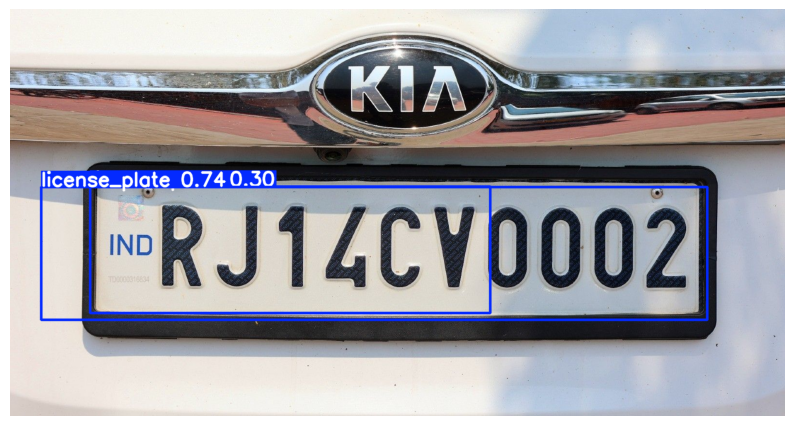

Plate detected at: x1=65, y1=367, x2=1439, y2=642
Confidence: 0.74
Plate detected at: x1=165, y1=366, x2=992, y2=628
Confidence: 0.30


In [34]:
import cv2
from matplotlib import pyplot as plt

image_path = "/content/fancy_number_plate_bfbc501f34.jpg"

results = model(image_path)

for result in results:
    img = result.plot()
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

    if len(result.boxes) > 0:
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf = box.conf[0].item()
            print(f"Plate detected at: x1={x1:.0f}, y1={y1:.0f}, x2={x2:.0f}, y2={y2:.0f}")
            print(f"Confidence: {conf:.2f}")
    else:
        print("No plate detected in this image.")

In [63]:
import easyocr

reader = easyocr.Reader(['en'], gpu=True, verbose=False)

print("[OK] EasyOCR reader ready!")

[OK] EasyOCR reader ready!


In [67]:
import re

def clean_plate_text(raw_list):
    # Step 1: Sab join karo aur uppercase
    text = ' '.join(raw_list).upper()

    # Step 2: Sirf valid plate chars rakho (A-Z, 0-9)
    text = re.sub(r'[^A-Z0-9]', '', text)

    # Step 3: Common OCR mistakes fix karo
    ocr_fixes = {
        'O': '0',   # Letter O -> Zero
        'I': '1',   # Letter I -> One
        'L': '1',   # Letter L -> One
        'Z': '2',   # Letter Z -> Two
        'S': '5',   # Letter S -> Five
        'B': '8',   # Letter B -> Eight
    }

    # Indian plate format: RJ14CV0002
    # Pehle 2 = state letters, next 2 = digits, next 2 = letters, last 4 = digits
    if len(text) >= 8:
        cleaned = ''
        for i, ch in enumerate(text[:10]):  # Max 10 chars
            if i in [0,1,4,5]:       # Letter positions
                cleaned += ch
            else:                    # Digit positions - fix karo
                cleaned += ocr_fixes.get(ch, ch)
        return cleaned
    return text


# ── Test ─────────────────────────────────────────────────────
raw_ocr = ['IND RJILCYOOOZ TCCOSXI']
result  = clean_plate_text(raw_ocr)
print(f"Raw:     IND RJILCYOOOZ TCCOSXI")
print(f"Cleaned: {result}")
# Expected output: RJ14CV0002

Raw:     IND RJILCYOOOZ TCCOSXI
Cleaned: INDRJI1CY0


In [70]:
import cv2, re
from ultralytics import YOLO
import easyocr

model  = YOLO('/content/drive/MyDrive/ANPR_System/models/best.pt')
reader = easyocr.Reader(['en'], gpu=True, verbose=False)

def get_best_part(raw_list):
    best = ''
    for part in raw_list:
        cleaned = re.sub(r'[^A-Za-z0-9]', '', part)
        has_letter = bool(re.search(r'[A-Za-z]', cleaned))
        has_digit  = bool(re.search(r'[0-9]', cleaned))
        if has_letter and has_digit and len(cleaned) >= 5:
            if len(cleaned) > len(best):
                best = cleaned
    return best if best else ''.join(raw_list)

def clean_plate(text):
    text = re.sub(r'[^A-Z0-9]', '', text.upper())
    fixes = {'O':'0', 'I':'1', 'L':'1', 'Z':'2', 'S':'5', 'B':'8'}
    letter_pos = {0,1,4,5}
    cleaned = ''
    for i, ch in enumerate(text[:10]):
        cleaned += ch if i in letter_pos else fixes.get(ch, ch)
    return cleaned

img     = cv2.imread('/content/fancy_number_plate_bfbc501f34.jpg')
results = model.predict(img, conf=0.5, verbose=False)

for box in results[0].boxes:
    x1,y1,x2,y2 = map(int, box.xyxy[0])
    conf         = float(box.conf[0])
    crop         = img[y1:y2, x1:x2]

    raw       = reader.readtext(crop, detail=0)
    best_part = get_best_part(raw)
    plate     = clean_plate(best_part)

    print(f"Raw OCR : {raw}")
    print(f"Selected: {best_part}")
    print(f"Plate   : {plate}")
    print(f"Conf    : {conf:.2f}")
    print("-"*30)

Raw OCR : ['IND', 'RJiLcyoooz', 'TCCOSXI']
Selected: INDRJiLcyooozTCCOSXI
Plate   : INDRJI1CY0
Conf    : 0.74
------------------------------


In [71]:
# detail=1 → (bbox, text, confidence) teenon return karta hai
raw_detailed = reader.readtext(crop, detail=1)

print("── OCR Raw Output ──────────────────")
for (bbox, text, conf) in raw_detailed:
    print(f"  Text : {text}")
    print(f"  Conf : {conf:.2f}")
    print(f"  BBox : {bbox}")
    print()

# ── Sirf high-confidence results rakho (threshold = 0.3) ──────
CONF_THRESHOLD = 0.3

filtered_texts = [
    text
    for (_, text, conf) in raw_detailed
    if conf >= CONF_THRESHOLD
]

avg_conf = (
    sum(conf for _,_,conf in raw_detailed if conf >= CONF_THRESHOLD)
    / max(len(filtered_texts), 1)
)

print("── Filtered Output ─────────────────")
print(f"  Kept  : {filtered_texts}")
print(f"  Avg Conf: {avg_conf:.2f}")

if not filtered_texts:
    print("  [WARN] No text above threshold — plate unreadable")

── OCR Raw Output ──────────────────
  Text : IND
  Conf : 0.95
  BBox : [[np.int32(135), np.int32(89)], [np.int32(239), np.int32(89)], [np.int32(239), np.int32(151)], [np.int32(135), np.int32(151)]]

  Text : RJiLcyoooz
  Conf : 0.16
  BBox : [[np.int32(233), np.int32(19)], [np.int32(1359), np.int32(19)], [np.int32(1359), np.int32(229)], [np.int32(233), np.int32(229)]]

  Text : TCCOSXI
  Conf : 0.00
  BBox : [[np.int32(139), np.int32(183)], [np.int32(227), np.int32(183)], [np.int32(227), np.int32(199)], [np.int32(139), np.int32(199)]]

── Filtered Output ─────────────────
  Kept  : ['IND']
  Avg Conf: 0.95


✓ Plate : ABD123  |  Conf: 0.80


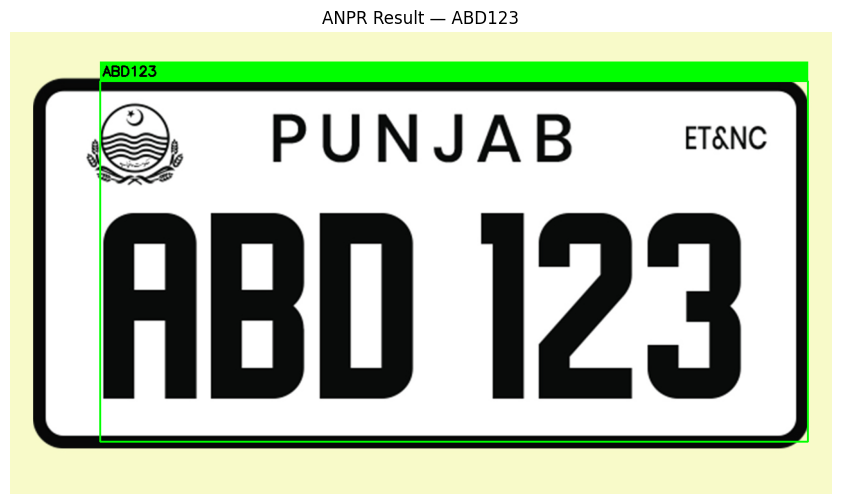

In [77]:
import cv2, re, os
import numpy as np
import easyocr
from ultralytics import YOLO
from datetime import datetime
import csv
import matplotlib.pyplot as plt

# ── 1. Models ────────────────────────────────────────────────
model  = YOLO('/content/drive/MyDrive/ANPR_System/models/best.pt')
reader = easyocr.Reader(['en'], gpu=True, verbose=False)

# ── 2. Helper functions ───────────────────────────────────────
def get_best_part(raw_list):
    best = ''
    for part in raw_list:
        c = re.sub(r'[^A-Za-z0-9]', '', part)
        if re.search(r'[A-Za-z]', c) and re.search(r'[0-9]', c) and len(c) >= 5:
            if len(c) > len(best): best = c
    return best if best else ''.join(raw_list)

def clean_plate(text):
    text = re.sub(r'[^A-Z0-9]', '', text.upper())
    fixes = {'O':'0','I':'1','L':'1','Z':'2','S':'5','B':'8'}
    letter_pos = {0,1,4,5}
    cleaned = ''
    for i, ch in enumerate(text[:10]):
        cleaned += ch if i in letter_pos else fixes.get(ch, ch)
    return cleaned

# ── 3. Main pipeline function ─────────────────────────────────
def run_anpr(image_path, save_output=True, log_csv=True):
    img = cv2.imread(image_path)
    if img is None:
        print(f"[ERROR] Image not found: {image_path}")
        return

    results  = model.predict(img, conf=0.5, verbose=False)
    output   = img.copy()
    img_name = os.path.basename(image_path)
    plates   = []

    if len(results[0].boxes) == 0:
        print("[WARN] No plate detected!")
        return

    for box in results[0].boxes:
        x1,y1,x2,y2 = map(int, box.xyxy[0])
        conf         = float(box.conf[0])
        crop         = img[y1:y2, x1:x2]

        raw   = reader.readtext(crop, detail=0)
        best  = get_best_part(raw)
        plate = clean_plate(best)
        plates.append((plate, conf))

        cv2.rectangle(output, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.rectangle(output, (x1,y1-30), (x2,y1), (0,255,0), -1)
        cv2.putText(output, plate, (x1+4, y1-8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,0), 2)

        print(f"✓ Plate : {plate}  |  Conf: {conf:.2f}")

    if log_csv:
        with open('/content/anpr_log.csv', 'a', newline='') as f:
            w = csv.writer(f)
            for plate, conf in plates:
                w.writerow([img_name, plate, round(conf,2),
                              datetime.now().strftime('%Y-%m-%d %H:%M:%S')])

    if save_output:
        out_path = '/content/resizes.jpg'
        cv2.imwrite(out_path, output)

    rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12,6))
    plt.imshow(rgb); plt.axis('off')
    plt.title(f"ANPR Result — {', '.join(p for p,_ in plates)}")
    plt.show()

# ── 4. Run karo ──────────────────────────────────────────────
run_anpr('/content/resizes.jpg')

In [74]:
import shutil, os
import easyocr

# ── Step 1: Drive folder banao ───────────────────────────────
DRIVE_PATH = '/content/drive/MyDrive/ANPR_Project/easyocr_models'
os.makedirs(DRIVE_PATH, exist_ok=True)

# ── Step 2: Seedha Drive mein load karo
reader = easyocr.Reader(
    ['en'],
    gpu=True,
    verbose=True,
    model_storage_directory=DRIVE_PATH
)

print("\n[OK] EasyOCR models Drive mein save ho gaye!")
print(f"     Path: {DRIVE_PATH}")
print(f"     Files: {os.listdir(DRIVE_PATH)}")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete
[OK] EasyOCR models Drive mein save ho gaye!
     Path: /content/drive/MyDrive/ANPR_Project/easyocr_models
     Files: ['craft_mlt_25k.pth', 'english_g2.pth']


In [76]:
model  = YOLO('/content/drive/MyDrive/ANPR_System/models/best.pt')

reader = easyocr.Reader(
    ['en'],
    gpu=True,
    verbose=False,
    model_storage_directory='/content/drive/MyDrive/ANPR_Project/easyocr_models'
)

print("[OK] Models loaded from Drive")

[OK] Models loaded from Drive
